In [9]:
from Seera import Sequential,Conv2D,Dense,MaxPool2D,Flatten,Adam,Loss,Input
from Dataset import MNIST
import matplotlib.pyplot as plt
import numpy as np

In [10]:
(X,y),(X_test,y_test)=MNIST()
y_train=np.zeros((np.shape(y)[0],10))
for i in range (np.shape(y)[0]):
  y_train[i]=np.eye(10)[y[i]]
y_train=y_train.reshape(60000,10,1)
X_train=X.reshape(60000,1,28,28)/255
X_test=X_test.reshape((10000,1,28,28))/255


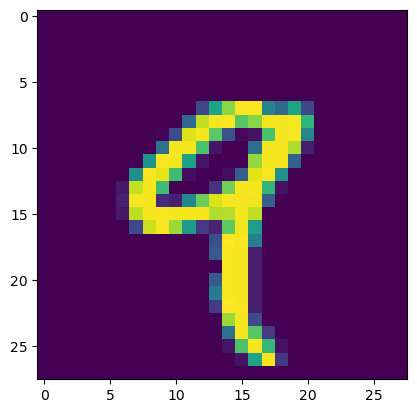

In [12]:
plt.imshow(X_train[4,0])

In [13]:
model2 = Sequential([
    Input(shape=(1,28,28)),
    
    Conv2D(32,1,(3,3),activation="relu",kernel_initializer="he_normal"),
    # Conv2D(32,32,(3,3),activation="relu",kernel_initializer="he_normal"),
    MaxPool2D(pool_size=(2,2),stride=2),
    
    Conv2D(16,32,(3,3),activation="relu",kernel_initializer="he_normal"),
    # Conv2D(16,16,(3,3),activation="relu",kernel_initializer="he_normal"),
    MaxPool2D(pool_size=(2,2),stride=2),
    
    Flatten(),
    
    Dense(400, 32, activation="relu", kernel_initializer="he_uniform"),
    Dense(32, 16, activation="relu", kernel_initializer="he_uniform"),
    Dense(16, 10, activation="softmax")
])

optim=Adam(model2,lr=5e-4)
loss=Loss().categorical_cross_entropy